Problem:       House-price prediction

ML type:       Supervised learning

Task:          Regression

Inputs:        Size, bedrooms, age

Target:        House price

Model:         Multiple linear regression

Goal:          Make accurate predictions on unseen houses

In [1]:
# Create the dataset

import numpy as np
import pandas as pd

data = {
    "size_sqft": [850, 1000, 1200, 1350, 1500, 1650, 1800, 2000, 2200, 2500],
    "bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "age_years": [20, 15, 10, 12, 8, 7, 5, 4, 3, 2],
    "price": [180000, 210000, 250000, 270000, 300000,
              330000, 360000, 400000, 450000, 510000]
}

df = pd.DataFrame(data)

print(df)

   size_sqft  bedrooms  age_years   price
0        850         2         20  180000
1       1000         2         15  210000
2       1200         3         10  250000
3       1350         3         12  270000
4       1500         3          8  300000
5       1650         4          7  330000
6       1800         4          5  360000
7       2000         4          4  400000
8       2200         5          3  450000
9       2500         5          2  510000


In [2]:
print(df.shape)

(10, 4)


In [3]:
print(df.columns)

Index(['size_sqft', 'bedrooms', 'age_years', 'price'], dtype='str')


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   size_sqft  10 non-null     int64
 1   bedrooms   10 non-null     int64
 2   age_years  10 non-null     int64
 3   price      10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes
None


In [5]:
print(df.describe())

         size_sqft   bedrooms  age_years          price
count    10.000000  10.000000  10.000000      10.000000
mean   1605.000000   3.500000   8.600000  326000.000000
std     529.910894   1.080123   5.738757  105535.670642
min     850.000000   2.000000   2.000000  180000.000000
25%    1237.500000   3.000000   4.250000  255000.000000
50%    1575.000000   3.500000   7.500000  315000.000000
75%    1950.000000   4.000000  11.500000  390000.000000
max    2500.000000   5.000000  20.000000  510000.000000


In [6]:
print(df.isnull().sum())

size_sqft    0
bedrooms     0
age_years    0
price        0
dtype: int64


In [7]:
X = df[['size_sqft', 'bedrooms', 'age_years']]
y = df['price']

print(X)
print(y)

   size_sqft  bedrooms  age_years
0        850         2         20
1       1000         2         15
2       1200         3         10
3       1350         3         12
4       1500         3          8
5       1650         4          7
6       1800         4          5
7       2000         4          4
8       2200         5          3
9       2500         5          2
0    180000
1    210000
2    250000
3    270000
4    300000
5    330000
6    360000
7    400000
8    450000
9    510000
Name: price, dtype: int64


In [8]:
X = X.to_numpy()
y = y.to_numpy()

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (10, 3)
Y shape: (10,)


In [9]:
# Train/Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8, 3)
X_test: (2, 3)
y_train: (8,)
y_test: (2,)


In [11]:
import matplotlib.pyplot as plt

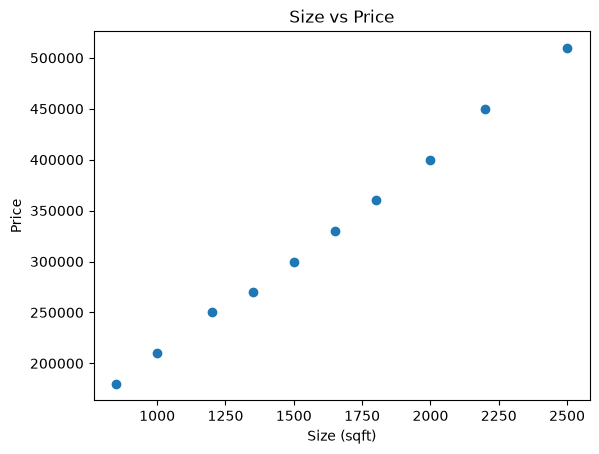

In [12]:
# Size vs Price

plt.scatter(df["size_sqft"], df["price"])

plt.xlabel("Size (sqft)")
plt.ylabel("Price")
plt.title("Size vs Price")

plt.show()

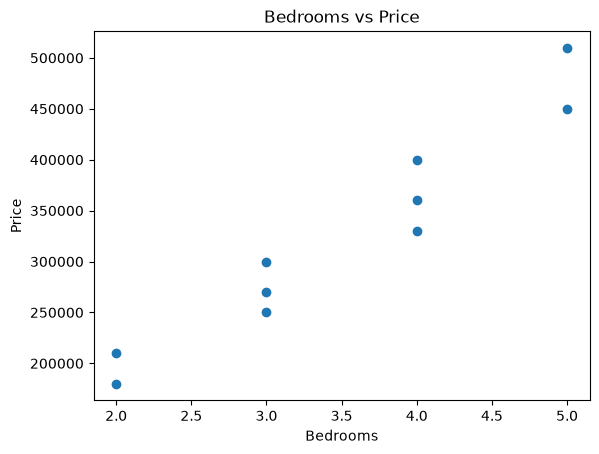

In [13]:
# Bedrooms vs Price

plt.scatter(df["bedrooms"], df["price"])

plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Bedrooms vs Price")

plt.show()

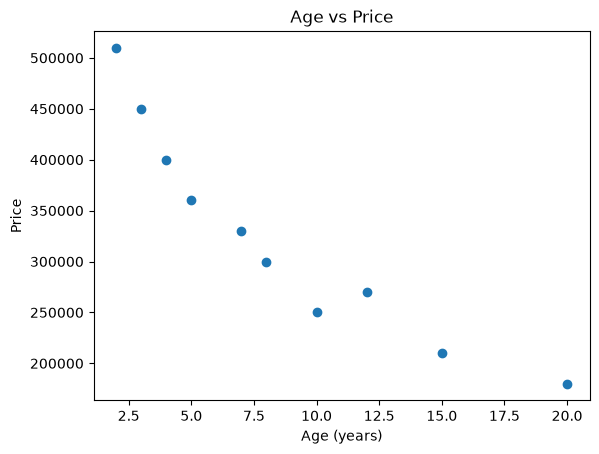

In [14]:
# Age vs Price

plt.scatter(df["age_years"], df["price"])

plt.xlabel("Age (years)")
plt.ylabel("Price")
plt.title("Age vs Price")

plt.show()

In [15]:
print(X_train.shape)
print(y_train.shape)

(8, 3)
(8,)


In [16]:
# Prediction

def predict_multi(X, w, b):
    return X @ w + b

In [17]:
# Cost funtion

def compute_cost_multi(X, y, w, b):
    m = len(y)
    
    predictions = predict_multi(X, w, b)
    errors = predictions - y
    
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    
    return cost

In [18]:
# Gradient

def compute_gradient_multi(X, y, w, b):
    m = len(y)
    
    predictions = predict_multi(X, w, b)
    errors = predictions - y
    
    dj_dw = (1 / m) * (X.T @ errors)
    dj_db = (1 / m) * np.sum(errors)
    
    return dj_dw, dj_db

In [19]:
# Gradient descent

def gradient_descent_multi(X, y, w, b, alpha, num_iters):
    
    cost_history = []
    
    for i in range(num_iters):
        
        dj_dw, dj_db = compute_gradient_multi(X, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost = compute_cost_multi(X, y, w, b)
        cost_history.append(cost)
        
    return w, b, cost_history

In [20]:
w_init = np.zeros(X_train.shape[1])
b_init = 0.0

print("Initial w:", w_init)
print("Initial b:", b_init)

Initial w: [0. 0. 0.]
Initial b: 0.0


In [21]:
alpha = 1e-9
num_iters = 5000

In [22]:
w_final, b_final, cost_history = gradient_descent_multi(
    X_train,
    y_train,
    w_init,
    b_init,
    alpha,
    num_iters,
)

In [23]:
print("Final weights:", w_final)
print("Final bias:", b_final)

Final weights: [202.02217164   0.4348351    0.90154103]
Final bias: 0.11810980507928791


In [24]:
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])

Initial cost: 56954096678.623314
Final cost: 12970357.456041915


In [25]:
y_pred = predict_multi(X_test, w_final, b_final)

print("Actual prices:", y_test)
print("Predicted prices:", y_pred)

Actual prices: [450000 210000]
Predicted prices: [444453.77450979 202036.6825325 ]


In [26]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 6754.771478853931


In [27]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 47087521.13821318


In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.9967300332542908


R² ≈ 1     → predictions fit the test data very well

R² ≈ 0     → little improvement over the baseline

R² < 0     → worse than the baseline

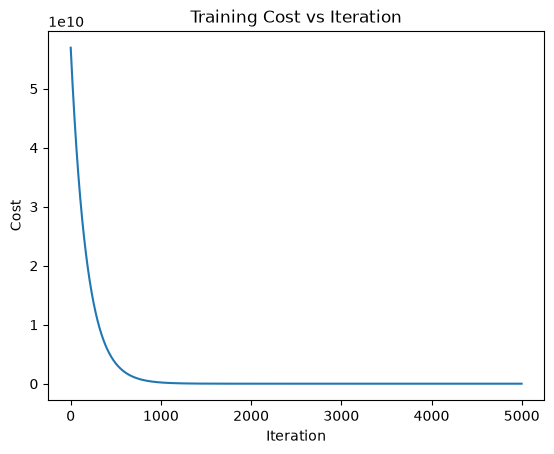

In [29]:
# Cost vs. iteration

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Training Cost vs Iteration")

plt.show()

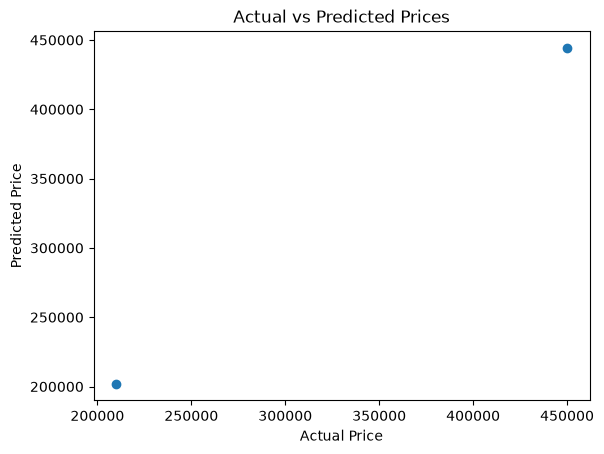

In [30]:
# Actual vs Predicted

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [31]:
print("Weights:")
print("Size:", w_final[0])
print("Bedrooms:", w_final[1])
print("Age:", w_final[2])

print("Bias:", b_final)

Weights:
Size: 202.02217163698484
Bedrooms: 0.4348351042384864
Age: 0.9015410333811501
Bias: 0.11810980507928791
